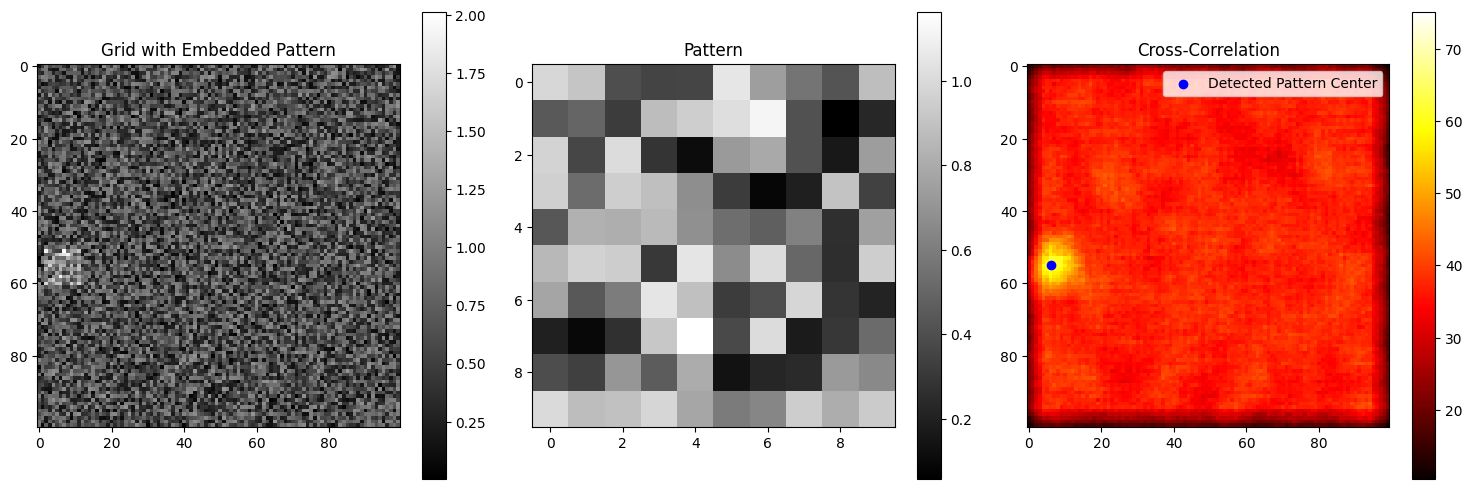

Original Pattern Location: (51, 2)
Detected Pattern Location: (55, 6)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d

# Step 1: Generate a 2D Grid
grid_size = (100, 100)  # Size of the grid
grid = np.random.rand(*grid_size)  # Random noise

# Step 2: Generate a 2D Pattern
pattern_size = (10, 10)  # Size of the pattern
pattern = np.random.rand(*pattern_size)

# Embed the pattern in the grid at a random location
embed_x = np.random.randint(0, grid_size[0] - pattern_size[0])
embed_y = np.random.randint(0, grid_size[1] - pattern_size[1])
grid[embed_x:embed_x + pattern_size[0], embed_y:embed_y + pattern_size[1]] += pattern

# Add noise to the grid and pattern
grid += 0.2 * np.random.rand(*grid_size)  # Noise level for grid
pattern += 0.2 * np.random.rand(*pattern_size)  # Noise level for pattern

# Step 3: Compute 2D Cross-Correlation
correlation = correlate2d(grid, pattern, mode='same')

# Step 4: Find the Peak of Cross-Correlation
detected_x, detected_y = np.unravel_index(np.argmax(correlation), correlation.shape)

# Step 5: Visualization
plt.figure(figsize=(15, 5))

# Original Grid
plt.subplot(1, 3, 1)
plt.imshow(grid, cmap='gray')
plt.title("Grid with Embedded Pattern")
plt.colorbar()

# Pattern
plt.subplot(1, 3, 2)
plt.imshow(pattern, cmap='gray')
plt.title("Pattern")
plt.colorbar()

# Cross-Correlation
plt.subplot(1, 3, 3)
plt.imshow(correlation, cmap='hot')
plt.title("Cross-Correlation")
plt.colorbar()

# Highlight detected location
plt.scatter([detected_y], [detected_x], color='blue', label='Detected Pattern Center')
plt.legend()
plt.tight_layout()
plt.show()

# Print results
print(f"Original Pattern Location: ({embed_x}, {embed_y})")
print(f"Detected Pattern Location: ({detected_x}, {detected_y})")
